### Source Attribution  

This notebook is adapted from the **Neuromatch Academy (NMA) – Computational Neuroscience Course**,  
**Python Workshop Intro to Modeling** tutorial.  

Original authors: *Neuromatch Academy Contributors*  
Source:

Github : [Neuromatch Academy GitHub Repository](https://github.com/NeuromatchAcademy/course-content)  
Tutorial : [Neuromatch computational neuroscience course](https://compneuro.neuromatch.io/tutorials/intro.html)

License: [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)  

> Adapted and modified by *Vaishnavi Gawale* for learning and documentation purposes as part of the **BCI Learning Series**.


# **What models** are used to describe the data.

To understand what our data looks like, we will try to analyse the data, visualize it in different ways and will try to develop a simple model.

Tasks :

1. Load a dataset with spiking activity from neurons and understand how it is organized

2. Make plots to visualize characteristics of the spiking activity across the population

3. Compute the distribution of “inter-spike intervals” (ISIs) for a single neuron


We will try to understand the neural data. What models are used to describe the data.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Plotting the function

In [ ]:
# @title Plotting functions

def plot_isis(single_neuron_isis):
  plt.hist(single_neuron_isis, bins=50, histtype="stepfilled")
  plt.axvline(single_neuron_isis.mean(), color="orange", label="Mean ISI")
  plt.xlabel("ISI duration (s)")
  plt.ylabel("Number of spikes")
  plt.legend()

#### Download the dataset
A subset of Steinmetz et al.(2009) is downloaded and used. This has spiking neuron data of mice.

In [ ]:
import io
import requests
r = requests.get('https://osf.io/sy5xt/download')
if r.status_code != 200:
  print("Failes to download")
else:
  spike_times = np.load(io.BytesIO(r.content), allow_pickle=True)['spike_times']

Understanding the spike_times variable


In [ ]:
type(spike_times)

numpy.ndarray

Its is an numpy array

In [ ]:
spike_times.shape

(734,)

Array is of one dimension with 734 entries.


In [ ]:
idx = 0
print(
    type(spike_times[idx]),
    spike_times[idx].shape,
    sep="\n"
)

<class 'numpy.ndarray'>
(826,)


1st enrty has 734 rows, at 1st row value theres is array of 826 values.
Why didn’t this show up as a second dimension in the shape of spike_times? That is, why not spike_times.shape == (734, 826)?



In [ ]:
idx = 321
print(
    type(spike_times[idx]),
    spike_times[idx].shape,
    sep="\n"
)

<class 'numpy.ndarray'>
(9723,)


Shape of every array at different position is different. Checking the NumPy types of the values in these arrays, and their first few elements,

In [ ]:
i_neurons = [0, 321]
i_print = slice(0, 5)

for i in i_neurons:
  print(
      f"Neuron {i} :",
      spike_times[i].dtype,
      spike_times[i].shape,
      spike_times[i][i_print],
      "\n",
      sep="\n"
  )

Neuron 0 :
float32
(826,)
[ 0.8149   14.822467 24.9646   25.1436   38.8709  ]


Neuron 321 :
float32
(9723,)
[1.0698667 1.1536334 1.2403667 1.7072    1.799    ]




- spike_times is 1D, its entries are NumPy arrays, and its length is the number of neurons (734): by indexing it, we select a subset of neurons.

- An array in spike_times is also 1D and corresponds to a single neuron; its entries are floating point numbers, and its length is the number of spikes attributed to that neuron. By indexing it, we select a subset of spike times for that neuron.

In [ ]:
n_neurons = len(spike_times)
total_spikes_per_neuron = [len(spike_times[i]) for i in range(n_neurons)]
print("Total Neurons :", n_neurons)
print("Total spikes per neuron :" ,total_spikes_per_neuron[:5])

Total Neurons : 734
Total spikes per neuron : [826, 2818, 3953, 646, 1115]


In [ ]:
print(np.max(total_spikes_per_neuron))

125324


We have seen the no of spikes and its type. Lets find answer of these questions -

1. How many spikes per neuron?
2. What is the distribution of spikes?

Text(0, 0.5, 'Number of Neurons')

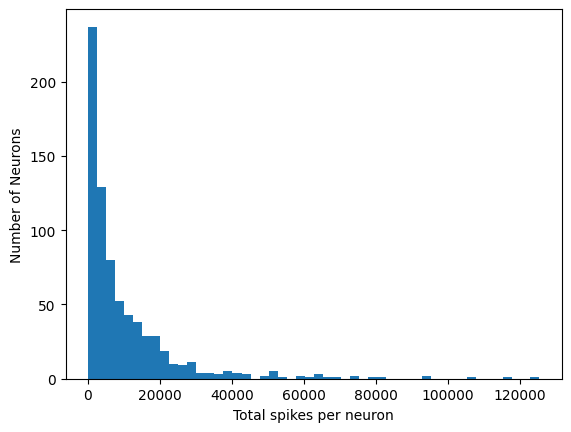

In [ ]:
plt.hist(total_spikes_per_neuron, bins=50, histtype="stepfilled")
plt.xlabel("Total spikes per neuron")
plt.ylabel("Number of Neurons")

Percentage of neurons below average spike count

In [ ]:
mean_spike_count = np.mean(total_spikes_per_neuron)
frac_below_mean = (total_spikes_per_neuron < mean_spike_count).mean()
print(f"{frac_below_mean:2.1%} of neurons are below the mean")

68.0% of neurons are below the mean


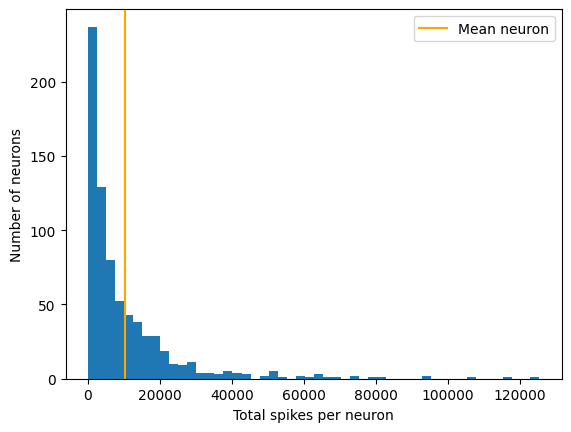

In [ ]:
plt.hist(total_spikes_per_neuron, bins=50, histtype="stepfilled")
plt.xlabel("Total spikes per neuron")
plt.ylabel("Number of neurons")
plt.axvline(mean_spike_count, color="orange", label="Mean neuron")
plt.legend();

This shows that the majority of neurons are relatively “quiet” compared to the mean, while a small number of neurons are exceptionally “loud”: they must have spiked more often to reach a large count.

what does that imply about the relationship between the mean neuron and the median neuron?

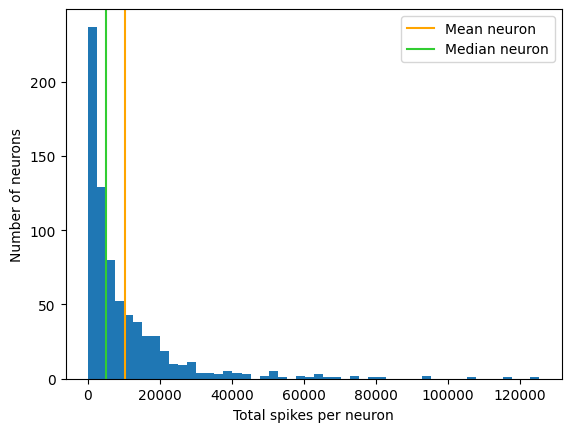

In [ ]:
median_spike_count = np.median(total_spikes_per_neuron)

plt.hist(total_spikes_per_neuron, bins=50, histtype="stepfilled")
plt.xlabel("Total spikes per neuron")
plt.ylabel("Number of neurons")
plt.axvline(mean_spike_count, color="orange", label="Mean neuron")
plt.axvline(median_spike_count, color="limegreen", label="Median neuron")
plt.legend();

### Visualizing neuronal spiking activity